<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/GFP_gene_Expression_by_morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

data collection


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the counts data
counts_df = pd.read_csv('rlog.counts.csv')

# 2. Define the GFP gene symbols found earlier
gfp_symbols = ['LOC111346784', 'LOC111344518']

# 3. Filter the rows for these symbols
# Note: 'Unnamed: 0' is the column containing gene symbols in rlog.counts.csv
gfp_counts = counts_df[counts_df['Unnamed: 0'].isin(gfp_symbols)]

# 4. Format the table for readability (Samples as rows)
gfp_counts = gfp_counts.rename(columns={'Unnamed: 0': 'Symbol'})
gfp_sample_table = gfp_counts.set_index('Symbol').transpose()
gfp_sample_table.index.name = 'Sample'
gfp_sample_table = gfp_sample_table.reset_index()

# 5. Add 'morph' column based on 'Sample' values
conditions = [
    gfp_sample_table['Sample'].isin(['pl_101', 'pl_102', 'pl_104', 'pl_106', 'pl_107'])
]
choices = ['HF']
gfp_sample_table['morph'] = np.select(conditions, choices, default='NF')

# 6. Save and display the result
gfp_sample_table.to_csv('gfp_expression_per_sample.csv', index=False)
print(gfp_sample_table)

Symbol  Sample  LOC111344518  LOC111346784 morph
0       pl_101      3.146035      3.895343    HF
1       pl_102      3.075049      3.711994    HF
2       pl_104      3.559639      5.088106    HF
3       pl_106      4.573439      4.866620    HF
4       pl_107      3.246406      3.940657    HF
5       pl_111      2.528381      2.554911    NF
6       pl_112      2.313016      2.911387    NF
7       pl_113      2.038195      2.406407    NF
8       pl_118      2.250179      2.622172    NF
9       pl_119      2.170540      2.725745    NF


check for normality and do mann whitney u

In [ ]:
from scipy.stats import mannwhitneyu
import pandas as pd

# Ensure gfp_melted is available (it was created for the boxplot)
# If not, recreate it:
if 'gfp_melted' not in locals():
    gfp_melted = gfp_sample_table.melt(id_vars=['Sample', 'morph'],
                                     value_vars=['LOC111344518', 'LOC111346784'],
                                     var_name='Gene', value_name='Expression')

print("Mann-Whitney U Test Results:")
print("----------------------------")

unique_genes = gfp_melted['Gene'].unique()

for gene in unique_genes:
    # Filter data for the current gene
    gene_data = gfp_melted[gfp_melted['Gene'] == gene]

    # Separate expression values for 'HF' and 'NF' morphs
    hf_expression = gene_data[gene_data['morph'] == 'HF']['Expression']
    nf_expression = gene_data[gene_data['morph'] == 'NF']['Expression']

    # Perform Mann-Whitney U test
    # We use alternative='two-sided' to check for any difference (not just greater/lesser)
    stat, p_value = mannwhitneyu(hf_expression, nf_expression, alternative='two-sided')

    print(f"Gene: {gene}")
    print(f"  U-statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("  -> Statistically significant difference between HF and NF morphs (p < 0.05)")
    else:
        print("  -> No statistically significant difference between HF and NF morphs (p >= 0.05)")
    print("\n")

Mann-Whitney U Test Results:
----------------------------
Gene: LOC111344518
  U-statistic: 25.0000
  P-value: 0.0079
  -> Statistically significant difference between HF and NF morphs (p < 0.05)


Gene: LOC111346784
  U-statistic: 25.0000
  P-value: 0.0079
  -> Statistically significant difference between HF and NF morphs (p < 0.05)




#### Interpreting Q-Q Plots:

*   **Straight line:** If the points on the Q-Q plot generally follow the diagonal line, it suggests that the data is approximately normally distributed.
*   **Deviations at ends:** Deviations from the line at the ends (tails) indicate heavier or lighter tails than a normal distribution.
*   **Curvature:** A curved pattern suggests skewness.

Since we have a relatively small number of data points per group, a perfectly straight line is unlikely. Look for general trends rather than absolute perfect alignment.

plotting

#### Interpreting Mann-Whitney U Test Results:

The Mann-Whitney U test is a non-parametric test used to compare two independent groups. It assesses whether two samples are drawn from the same population or from populations with the same distribution.

*   **P-value:** The p-value tells us the probability of observing a difference as extreme as, or more extreme than, the one we found, assuming there is no actual difference between the groups (the null hypothesis).
    *   **If P-value < 0.05 (commonly used significance level):** We reject the null hypothesis. This suggests there is a statistically significant difference in gene expression between the 'HF' and 'NF' morph groups for that particular gene.
    *   **If P-value >= 0.05:** We fail to reject the null hypothesis. This suggests there is no statistically significant difference in gene expression between the 'HF' and 'NF' morph groups, or our sample size is too small to detect one.

## Summary:

### Data Analysis Key Findings
*   The overarching 'Morph' label was successfully removed from the x-axis of the plot by setting the x-axis label in `g.set_axis_labels()` to an empty string.
*   The individual 'HF' and 'NF' tick labels, indicating the morph groups for each gene, were preserved on the x-axis.
*   The gene names continued to be displayed as facet titles above each subplot.
*   The plot effectively visualizes GFP gene expression levels for two genes ('LOC111344518' and 'LOC111346784') across 'HF' and 'NF' morph groups, including box plots, individual data points (stripplot), mean diamonds, and statistical significance annotations (p-values from Mann-Whitney U tests).

### Insights or Next Steps
*   The updated plot provides a cleaner and more concise visualization by removing redundant axis labels, enhancing readability without losing critical information.
*   Consider exploring other statistical tests or effect size measures to complement the p-value annotations for a more comprehensive understanding of the observed differences.


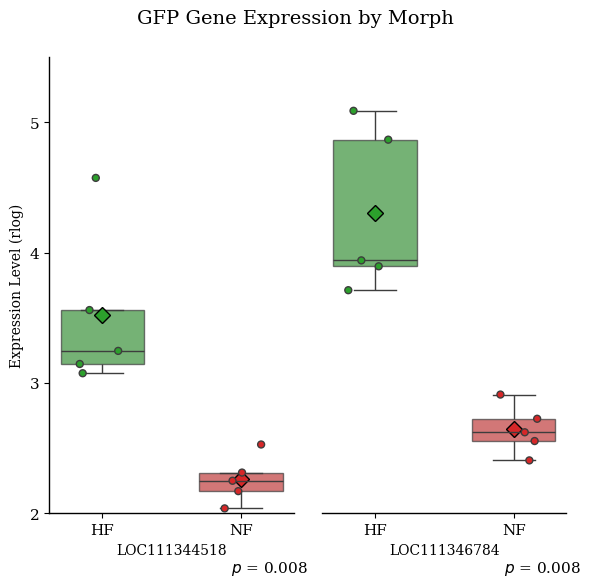

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import numpy as np

#STYLING
plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black', 'axes.linewidth': 1,
    'xtick.color': 'black', 'ytick.color': 'black',
    'text.color': 'black', 'axes.labelcolor': 'black',
    'legend.frameon': False,
    'ytick.labelsize': 11,
    'xtick.labelsize': 11
})
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
morph_order = ['HF', 'NF']

# Melt the DataFrame to long format for easier plotting with seaborn
gfp_melted = gfp_sample_table.melt(id_vars=['Sample', 'morph'],
                                 value_vars=['LOC111344518', 'LOC111346784'],
                                 var_name='Gene', value_name='Expression')

# Create a FacetGrid with 'Gene' on top (as columns)
g = sns.catplot(data=gfp_melted, x='morph', y='Expression', col='Gene',
                kind='box', col_order=gfp_melted['Gene'].unique(), # Ensure gene order
                hue='morph', palette=variant_colors, order=morph_order, # Ensure morph order and colors, added hue
                boxprops=dict(alpha=0.7), showmeans=False, showfliers=False, # Removed showmeans from catplot and hide default outliers
                height=6, aspect=0.5, sharey=True, width=0.6) # Explicitly sharey to ensure common y-axis scale, reduced aspect from 0.7 to 0.5

# Add stripplot to each facet
g.map_dataframe(sns.stripplot, x='morph', y='Expression',
                hue='morph', palette=variant_colors, order=morph_order, # Added hue
                jitter=0.2, dodge=False, edgecolor='auto', linewidth=1) # Set linewidth back to 1

# Calculate means for each gene and morph group
gene_morph_means = gfp_melted.groupby(['Gene', 'morph'])['Expression'].mean().reset_index()

# Add mean diamonds manually to each subplot
for i, gene in enumerate(gfp_melted['Gene'].unique()):
    ax = g.axes.flat[i] # Get the specific subplot for this gene
    gene_means = gene_morph_means[gene_morph_means['Gene'] == gene]

    for _, row in gene_means.iterrows():
        morph_val = row['morph']
        mean_val = row['Expression']
        color = variant_colors[morph_val]

        # Get x-position: 0 for HF, 1 for NF within each subplot
        x_pos = morph_order.index(morph_val)

        ax.plot(x_pos, mean_val, marker='D', markersize=8, markeredgecolor='black', markerfacecolor=color)


# Apply general styling and labels to each axis
g.set_axis_labels("", "Expression Level (rlog)") # Overall y-axis label
g.set_titles("") # Empty facet titles

# Manually control spines and tick labels for a single y-axis on the left
min_exp = gfp_melted['Expression'].min()
# max_exp = gfp_melted['Expression'].max() # Keep for setting ticks, but set ylim manually

# Calculate p-values beforehand to add to x-labels
p_values_dict = {}
alpha = 0.05 # Significance level
unique_genes = gfp_melted['Gene'].unique()
for gene in unique_genes:
    gene_data = gfp_melted[gfp_melted['Gene'] == gene]
    hf_expression = gene_data[gene_data['morph'] == 'HF']['Expression']
    nf_expression = gene_data[gene_data['morph'] == 'NF']['Expression']
    stat, p_value = mannwhitneyu(hf_expression, nf_expression, alternative='two-sided')
    p_values_dict[gene] = p_value

for i, ax in enumerate(g.axes.flat):
    current_gene = gfp_melted['Gene'].unique()[i]
    ax.set_yticks(np.arange(np.floor(min_exp), 5.5 + 1, 1)) # Set ticks up to 5.5
    ax.set_ylim(bottom=np.floor(min_exp), top=5.5) # Set y-axis limit to 5.5

    # Hide top and right spines for all subplots
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True) # Ensure bottom spine is always visible

    if i > 0: # For all subplots except the first one (which is the leftmost)
        ax.set_ylabel('') # Remove individual y-axis label
        ax.tick_params(axis='y', labelleft=False, left=False) # Remove y-tick labels and actual ticks
        ax.spines['left'].set_visible(False) # Hide left spine
    else: # For the first subplot (leftmost)
        ax.spines['left'].set_visible(True) # Ensure left spine is visible
        ax.tick_params(axis='y', labelleft=True, left=True) # Ensure y-tick labels and ticks are visible

    # Set only the gene name as the x-axis label for the current subplot (centered)
    ax.set_xlabel(current_gene)

    # Add p-value as a separate text annotation under 'NF' group
    p_val = p_values_dict[current_gene]
    p_text = f"$\\it{{p}}$ = {p_val:.3f}"
    # Position it under the 'NF' category (x=1) relative to the axes
    ax.text(0.9, -0.1, p_text, transform=ax.transAxes, ha='center', va='top', fontsize=plt.rcParams['xtick.labelsize'])

# Add a super title for the entire figure
plt.suptitle('GFP Gene Expression by Morph', y=0.98, fontsize=14) # Adjusted y from 1.02 to 1.00
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.savefig('GFP gene Expression by morph.png', dpi=600)
plt.show()

# Task
Move the gene name from the facet titles to the x-axis label of each subplot in the existing plotting code, while retaining the 'HF' and 'NF' x-tick labels, and then display the updated plot.

## Move Gene Name to X-axis Label

### Subtask:
Modify the plotting code to remove the gene name from the facet titles and set it as the x-axis label for each corresponding subplot. The individual 'HF' and 'NF' labels will remain as x-tick labels.


**Reasoning**:
I need to modify the existing plotting code to move the gene names from the facet titles to the x-axis labels of the individual subplots, as per the subtask instructions. This involves updating `g.set_titles` and adding `ax.set_xlabel(gene)` within the gene iteration loop.



## Final Task

### Subtask:
Present the updated plot to the user.


## Summary:

### Data Analysis Key Findings
*   The plotting code was successfully modified to remove gene names from facet titles by setting `g.set_titles("")`.
*   Gene names were moved to the x-axis label of each subplot using `ax.set_xlabel(gene)` within the iteration over unique genes.
*   The `g.set_axis_labels("", "Expression Level")` command ensured that the overall x-axis label for the `FacetGrid` remained empty, as required.
*   The 'HF' and 'NF' x-tick labels were correctly retained on each subplot.
*   The updated plot was generated successfully, incorporating all specified modifications.

### Insights or Next Steps
*   Integrating the gene name directly into the x-axis label for each subplot enhances the plot's readability by placing the gene identifier closer to its corresponding data, improving the clarity of individual comparisons.
*   This specific adjustment makes the plot more concise and visually appealing by removing redundant information from the facet titles.
